# 03. The Bayesian model, its failure and its repair, fitted by ADVI

**Goal.** Fit the structural time-series model by mean-field and
full-rank ADVI, use the exact variance decomposition to diagnose why it
loses to the seasonal naive at the 48-step horizon, and fit the repaired
model the diagnosis points to: the same regression with a stationary
AR(1) error in innovations form. Notebook 04 adjudicates the surrogates
against NUTS; notebook 05 compares all models.

## The trend formulation, states marginalised

On demand standardised over the fitting window:

$$
\begin{aligned}
y_t &\sim \mathcal{N}\!\left(\ell_t + x_t^\top \beta,\ \sigma_t^2\right),
&\log \sigma_t &= \gamma_0 + z_t^\top \gamma,\\
\ell_t &= \ell_{t-1} + b_{t-1} + \sigma_\ell\, \varepsilon^\ell_t,
&b_t &= \phi\, b_{t-1} + \sigma_b\, \varepsilon^b_t,
\qquad \varepsilon^\ell_t, \varepsilon^b_t \sim \mathcal{N}(0, 1),
\end{aligned}
$$

a local linear trend with damped slope, regression on the shared design
$x_t$ and a log-linear scale on the small variance design $z_t$.
Conditional on the hyperparameters the trend is linear-Gaussian, so a
Kalman filter inside the likelihood integrates the states out exactly
and inference runs over roughly fifty hyperparameters however long the
data. Sampling the states instead costs two dimensions per half hour:
tried on a 56-day window, cold NUTS did not finish 2,000 iterations in
seventeen hours and the full-rank guide diverged. Marginalisation fixes
the dimension problem but leaves a sequential filter inside every
gradient; that cost returns in notebook 04's hardware benchmarks.

## ADVI, ELBO watched in parts

ADVI maximises the evidence lower bound over a Gaussian surrogate $q$,
which splits exactly as

$$ \mathrm{ELBO} = \underbrace{\mathbb{E}_q[\log p(y, \theta)]}_{\text{energy}}
   + \underbrace{\mathbb{H}[q]}_{\text{entropy}}, $$

so under-dispersion is visible during training as entropy collapsing
while energy climbs. Two families throughout: mean-field (`AutoNormal`)
and full-rank (`AutoMultivariateNormal`), whose covariance can carry
the correlations mean-field discards.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")  # notebook JAX work is light; leave the GPU to fits

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.evaluation.metrics import crps_gaussian, crps_samples
from nemforecastdemand.models import bsts
from nemforecastdemand.models.predict import (
    variance_decomposition,
    variance_decomposition_innovations,
)
from nemforecastdemand.plotting import fan_chart, palette, save_figure, setup_style
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
splits = load_splits(cfg.paths.processed)
panel = pd.concat([splits["train"], splits["validation"], splits["test"]])
max_lag = max(cfg.features.demand_lags)

trend_fits = {
    kind: load_artifact(cfg.paths.artifacts / f"bsts_collapsed_vi_{kind}")
    for kind in ("meanfield", "fullrank")
}
ar_fits = {
    kind: load_artifact(cfg.paths.artifacts / f"bsts_innovations_vi_{kind}")
    for kind in ("meanfield", "fullrank")
}
trend_nuts, trend_nuts_meta = load_artifact(cfg.paths.artifacts / "bsts_collapsed_nuts_cold")
arima_arrays, arima_meta = load_artifact(cfg.paths.artifacts / "arima")

test_origins = rolling_origins(splits["test"].index, panel.index, cfg.origins, cfg.horizon, max_lag)
fit_index = panel.index[panel.index < splits["test"].index[0]][max_lag:]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)
y_test = trend_fits["meanfield"][0]["y_test"]
colours = {"meanfield": palette("demand"), "fullrank": palette("accent")}

TREND_SITES = tuple(s for s in bsts.HYPER_SITES if s not in ("level_init", "slope_init"))
AR_SITES = ("rho", "beta", "gamma0", "gamma")


def trend_draws(kind: str) -> dict[str, np.ndarray]:
    """Trend-model draws with the marginalised init sites at their prior mean."""
    arrays = trend_fits[kind][0]
    draws = {site: arrays[f"draw_{site}"] for site in TREND_SITES}
    zeros = np.zeros(draws["sigma_level"].shape[0], dtype=np.float32)
    return {**draws, "level_init": zeros, "slope_init": zeros}


def ar_draws(kind: str) -> dict[str, np.ndarray]:
    return {site: ar_fits[kind][0][f"draw_{site}"] for site in AR_SITES}


def per_horizon_crps(paths: np.ndarray) -> np.ndarray:
    """Mean CRPS at each lead time from sampled paths, (H,)."""
    return np.stack(
        [crps_samples(y_test[:, h], paths[:, :, h]).mean() for h in range(cfg.horizon)]
    )

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Diagnosis: where the trend model puts its variance

Mean-field, full-rank and NUTS agree on this model's forecasts to within
half a percent, so the failure is the model, not the inference. The
posterior shrinks the level innovation to nothing and inflates the slope
innovation to roughly five percent of a standard deviation per half
hour, damped at $\phi \approx 0.76$. A heavily damped, heavily driven
slope is a wiggle-tracker: excellent filtering (its one-step CRPS beats
every model in the project) but slope noise integrates into the level,
so by 48 steps the spread passes 2,000 MW where ARIMA sits near 700 and
the CRPS crosses ARIMA's at the third half hour.

In [2]:
sigma_slope = trend_nuts["post_sigma_slope"].ravel()
phi = trend_nuts["post_phi"].ravel()
pd.DataFrame(
    {
        "posterior mean": [
            trend_nuts["post_sigma_level"].ravel().mean() * inputs.y_scale,
            sigma_slope.mean() * inputs.y_scale,
            phi.mean(),
        ],
        "prior scale": [
            cfg.bsts.priors.level_scale * inputs.y_scale,
            cfg.bsts.priors.slope_scale * inputs.y_scale,
            np.nan,
        ],
    },
    index=["sigma_level (MW/step)", "sigma_slope (MW/step)", "phi (damping)"],
).round(2)

,posterior mean,prior scale
sigma_level (MW/step),1.530000,163.88
sigma_slope (MW/step),78.169998,16.39
phi (damping),0.760000,NaN


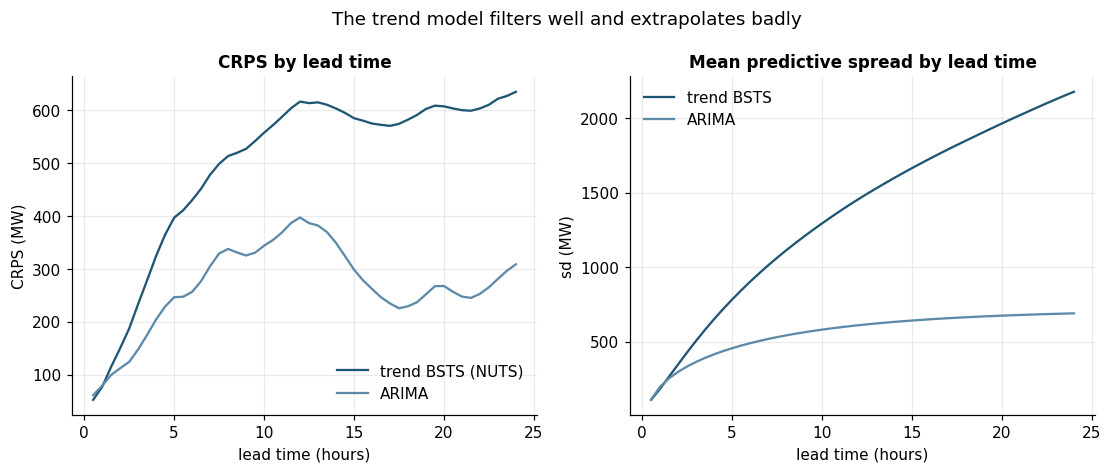

In [3]:
trend_curve = per_horizon_crps(trend_nuts["forecast_paths"])
arima_curve = np.stack(
    [
        crps_gaussian(
            y_test[:, h], arima_arrays["forecast_mean"][:, h], arima_arrays["forecast_sd"][:, h]
        ).mean()
        for h in range(cfg.horizon)
    ]
)
trend_sd = trend_nuts["forecast_paths"].std(axis=0).mean(axis=0)
hours = (np.arange(cfg.horizon) + 1) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hours, trend_curve, color=palette("demand"), label="trend BSTS (NUTS)")
axes[0].plot(hours, arima_curve, color=palette("forecast"), label="ARIMA")
axes[0].set_title("CRPS by lead time")
axes[0].set_ylabel("CRPS (MW)")
axes[1].plot(hours, trend_sd, color=palette("demand"), label="trend BSTS")
axes[1].plot(
    hours, arima_arrays["forecast_sd"].mean(axis=0), color=palette("forecast"), label="ARIMA"
)
axes[1].set_title("Mean predictive spread by lead time")
axes[1].set_ylabel("sd (MW)")
for ax in axes:
    ax.set_xlabel("lead time (hours)")
    ax.legend()
fig.suptitle("The trend model filters well and extrapolates badly", y=1.03)
save_figure(fig, "trend_model_diagnosis", cfg.paths.figures)
plt.show()

The variance decomposition attributes the blow-up. Given a draw the
model is linear-Gaussian, so predictive variance splits exactly into
**parameter** and **state** (epistemic) plus **process** and
**observation** (aleatoric). A sane day-ahead model is dominated by the
observation term; this one is dominated by process noise. Scores say
the model is bad, the decomposition says which component did it.

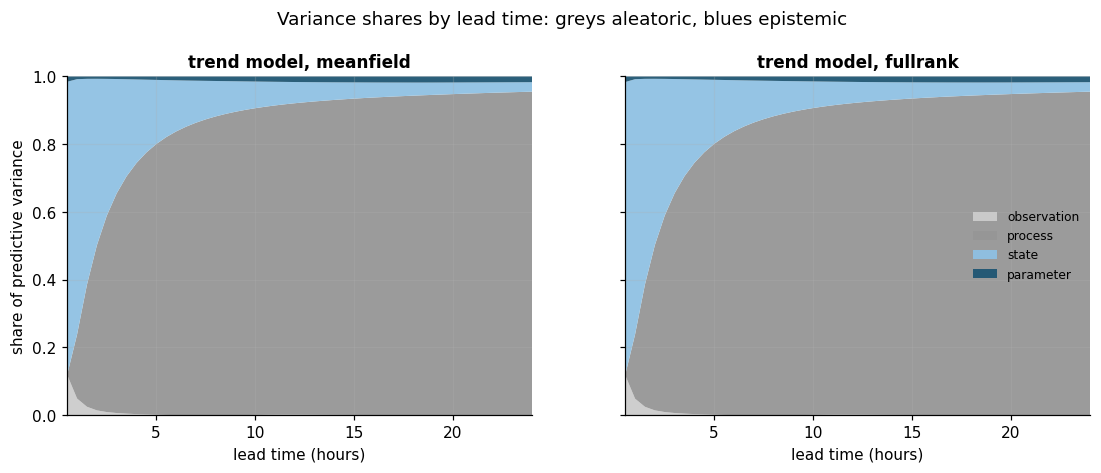

In [4]:
trend_decomp = {
    kind: variance_decomposition(trend_draws(kind), inputs, panel, cfg, test_origins)
    for kind in trend_fits
}

component_order = ["observation", "process", "state", "parameter"]
component_colours = {
    "observation": "#cccccc",
    "process": "#969696",
    "state": "#8fc1e3",
    "parameter": "#1f5673",
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, kind in zip(axes, trend_fits, strict=True):
    parts = trend_decomp[kind]
    total = sum(parts.values())
    shares = np.stack([(parts[name] / total).mean(axis=0) for name in component_order])
    ax.stackplot(
        hours,
        shares,
        labels=component_order,
        colors=[component_colours[n] for n in component_order],
        alpha=0.95,
    )
    ax.set_title(f"trend model, {kind}")
    ax.set_xlabel("lead time (hours)")
    ax.set_ylim(0, 1)
    ax.set_xlim(hours[0], hours[-1])
axes[0].set_ylabel("share of predictive variance")
axes[1].legend(loc="center right", fontsize=8)
fig.suptitle("Variance shares by lead time: greys aleatoric, blues epistemic", y=1.03)
save_figure(fig, "bsts_vi_variance_decomposition", cfg.paths.figures)
plt.show()

In [5]:
rows = {}
for kind in trend_fits:
    parts = trend_decomp[kind]
    total = sum(parts.values())
    rows[kind] = {f"{name} share": float((parts[name] / total).mean()) for name in component_order}
    rows[kind]["mean predictive sd (MW)"] = float(np.sqrt(total.mean()))
pd.DataFrame(rows).T.round(3)

,observation share,process share,state share,parameter share,mean predictive sd (MW)
meanfield,0.005,0.839,0.141,0.015,1490.692
fullrank,0.005,0.839,0.141,0.015,1487.797


## Repair: a stationary error in innovations form

Order selection in notebook 02 chose ARIMA(1, 0, 1): stationary
short-memory errors around the regression, no integrated trend. The
repair gives the Bayesian model the same structure,

$$ e_t = y_t - x_t^\top \beta, \qquad
   e_t - \rho\, e_{t-1} \sim \mathcal{N}(0, \sigma_t^2), \qquad
   \log \sigma_t = \gamma_0 + z_t^\top \gamma, $$

with the first residual at its stationary distribution and a Beta(8, 2)
prior on $\rho$. Writing the likelihood on the innovations has two
consequences. Nothing is sequential: residuals are one matrix product,
innovations a shifted difference, so the scan disappears from every
gradient. And because the error is first-order Markov, prediction
conditions on the observed residual at the origin; no filter, and the
state term of the decomposition is structurally zero.

Two honesty notes. The revision was motivated by the trend model's test
failure, a post-hoc structural repair; nothing in it was tuned on test
(structure follows the validation-selected ARIMA order, priors were
fixed before fitting, inference settings carry over). And the trend
model reaches a *higher* ELBO, because the wiggle-tracking slope buys
one-step density: in-sample evidence does not select for 48-step
forecasting, which is why rolling test origins decide.

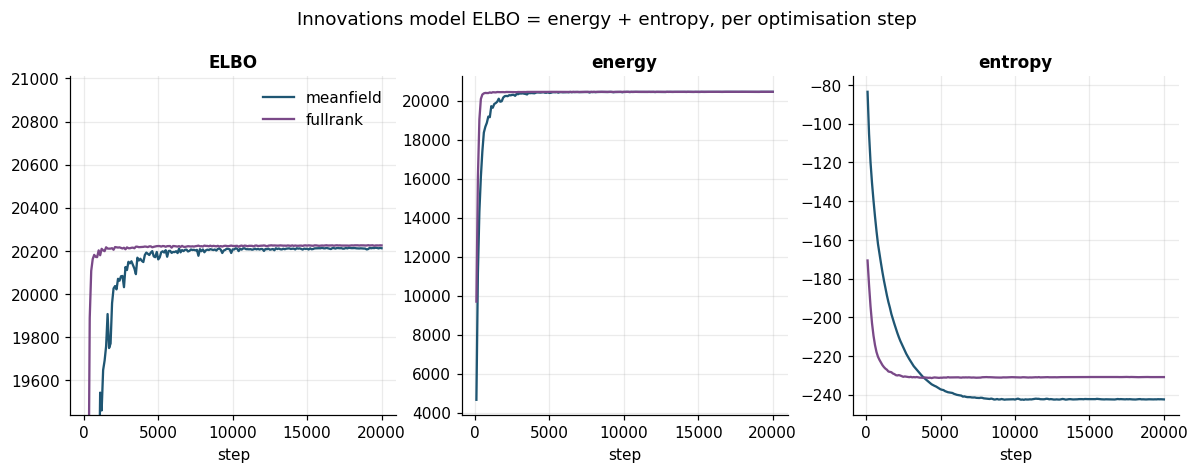

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for kind, (arrays, _meta) in ar_fits.items():
    axes[0].plot(arrays["elbo_steps"], arrays["elbo"], color=colours[kind], label=kind)
    axes[1].plot(arrays["elbo_steps"], arrays["energy"], color=colours[kind])
    axes[2].plot(arrays["elbo_steps"], arrays["entropy"], color=colours[kind])
for ax, title in zip(axes, ("ELBO", "energy", "entropy"), strict=True):
    ax.set_title(title)
    ax.set_xlabel("step")
axes[0].set_ylim(bottom=np.quantile(ar_fits["meanfield"][0]["elbo"], 0.05))
axes[0].legend()
fig.suptitle("Innovations model ELBO = energy + entropy, per optimisation step", y=1.03)
save_figure(fig, "elbo_decomposition", cfg.paths.figures)
plt.show()

In [7]:
def plateau_drift(elbo: np.ndarray, window: int = 20) -> str:
    """Relative ELBO drift between the last two checkpoint windows."""
    recent = elbo[-window:].mean()
    previous = elbo[-2 * window : -window].mean()
    return f"{abs(recent - previous) / abs(previous):.2%}"


pd.DataFrame(
    {
        f"{model} {kind}": {
            "final ELBO": meta["final_elbo"],
            "plateau drift, last 2k steps": plateau_drift(arrays["elbo"]),
            "fit seconds": meta["timings_seconds"]["fit_seconds"],
            "device": meta["device"],
        }
        for model, fits in (("trend", trend_fits), ("AR", ar_fits))
        for kind, (arrays, meta) in fits.items()
    }
).T

,final ELBO,"plateau drift, last 2k steps",fit seconds,device
trend meanfield,20623.925781,0.00%,3351.86493,gpu
trend fullrank,20629.681641,0.00%,3358.002255,gpu
AR meanfield,20212.800781,0.00%,3.127372,gpu
AR fullrank,20225.8125,0.00%,3.75701,gpu


The cost column is the second dividend: the same optimiser and step
budget that needed close to an hour against the Kalman scan finishes in
seconds without it.

## What the two surrogate families disagree about

Persistence and the variance head trade off against the regression (a
larger $\rho$ carries more of each residual, demanding less of
$\beta$), so this posterior is where mean-field should under-disperse.
Notebook 04 settles which family is right.

In [8]:
rows = {}
for name in ("rho", "gamma0"):
    mf = ar_fits["meanfield"][0][f"draw_{name}"]
    fr = ar_fits["fullrank"][0][f"draw_{name}"]
    rows[name] = {
        "mean (MF)": mf.mean(),
        "sd (MF)": mf.std(),
        "sd (FR)": fr.std(),
        "sd ratio MF/FR": mf.std() / fr.std(),
    }
pd.DataFrame(rows).T.round(4)

,mean (MF),sd (MF),sd (FR),sd ratio MF/FR
rho,0.9407,0.0011,0.0015,0.7623
gamma0,-2.7794,0.0060,0.0057,1.0563


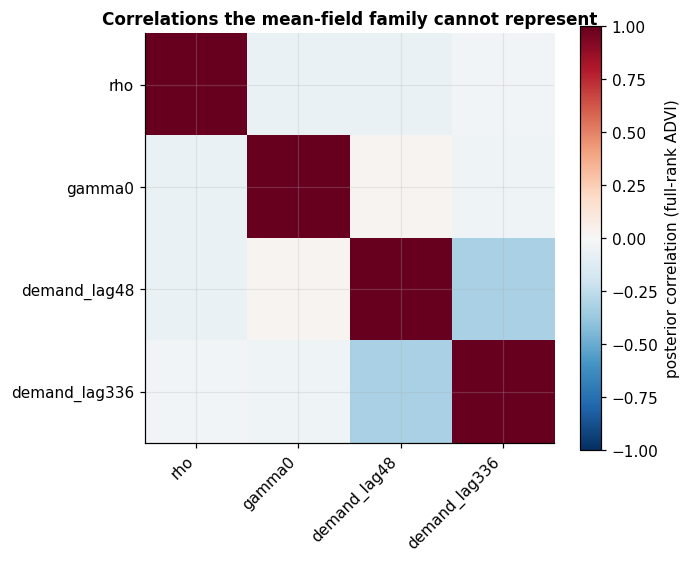

In [9]:
labels = ["rho", "gamma0"]
draws_fr = np.column_stack([ar_fits["fullrank"][0][f"draw_{name}"] for name in labels])
beta_fr = ar_fits["fullrank"][0]["draw_beta"]
lag_cols = [i for i, c in enumerate(inputs.columns) if "lag" in c]
draws_fr = np.column_stack([draws_fr, beta_fr[:, lag_cols]])
labels = labels + [inputs.columns[i] for i in lag_cols]
corr = np.corrcoef(draws_fr.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
fig.colorbar(im, label="posterior correlation (full-rank ADVI)")
ax.set_title("Correlations the mean-field family cannot represent")
plt.show()

## Persistence and the learned variance profile

The AR coefficient lands deep in the persistent regime and the variance
head keeps the daily risk profile: narrow bands in the small hours, wide
bands across the afternoon and evening ramps. The homoskedastic
ablation in notebooks 04 and 05 switches this head off to price it.

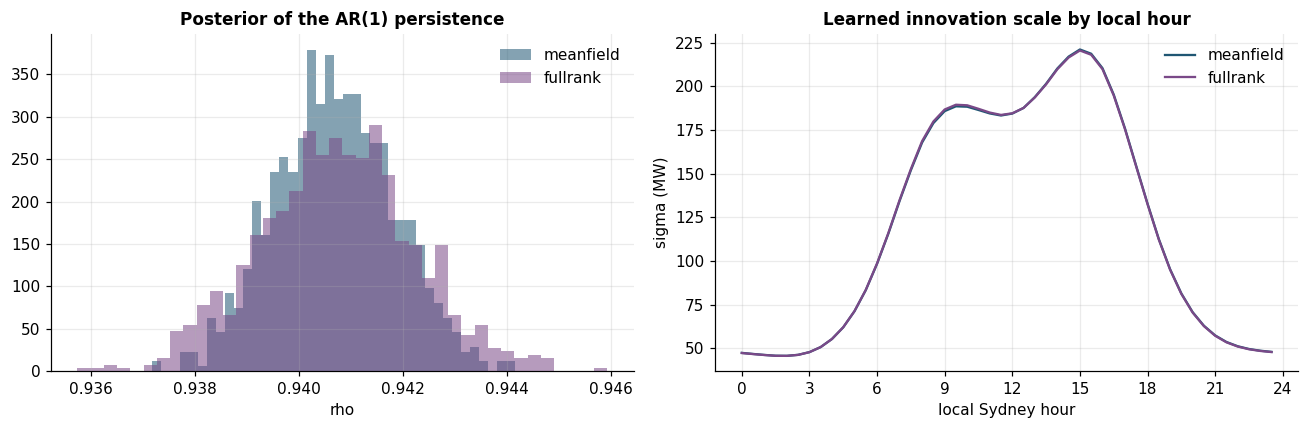

In [10]:
local_hour = fit_index.tz_convert("Australia/Sydney")
hour_frac = local_hour.hour + local_hour.minute / 60

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for kind in ar_fits:
    rho_draws = ar_fits[kind][0]["draw_rho"]
    axes[0].hist(rho_draws, bins=40, density=True, alpha=0.55, color=colours[kind], label=kind)
axes[0].set_title("Posterior of the AR(1) persistence")
axes[0].set_xlabel("rho")
axes[0].legend()

for kind in ar_fits:
    arrays = ar_fits[kind][0]
    gamma0 = arrays["draw_gamma0"][:, None]
    gamma = arrays["draw_gamma"]
    log_sigma = gamma0 + gamma @ inputs.x_var.T
    sigma_mw = np.exp(log_sigma) * inputs.y_scale
    profile = (
        pd.DataFrame({"hour": hour_frac, "sigma": sigma_mw.mean(axis=0)}).groupby("hour").mean()
    )
    axes[1].plot(profile.index, profile["sigma"], color=colours[kind], label=kind)
axes[1].set_title("Learned innovation scale by local hour")
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("sigma (MW)")
axes[1].set_xticks(np.arange(0, 25, 3))
axes[1].legend()
fig.tight_layout()
save_figure(fig, "bsts_trend_and_variance", cfg.paths.figures)
plt.show()

## Forecasts, before and after

Forecasts carry the observed origin residual forward under each draw's
$\rho$, innovations accumulating at the covariate-driven scale: one
coherent 48-step path per draw. CRPS uses the energy-form sample
estimator, unit-tested against the analytic Gaussian form.

In [11]:
crps_rows = {}
for kind, (arrays, _meta) in ar_fits.items():
    crps_rows[f"AR innovations, ADVI {kind}"] = float(
        np.mean(
            [
                crps_samples(y_test[i], arrays["forecast_paths"][:, i, :]).mean()
                for i in range(y_test.shape[0])
            ]
        )
    )
crps_rows["trend model, NUTS"] = float(
    np.mean(
        [
            crps_samples(y_test[i], trend_nuts["forecast_paths"][:, i, :]).mean()
            for i in range(y_test.shape[0])
        ]
    )
)
crps_rows["ARIMA baseline"] = float(
    crps_gaussian(
        arima_arrays["y_test"], arima_arrays["forecast_mean"], arima_arrays["forecast_sd"]
    ).mean()
)
pd.Series(crps_rows, name="test CRPS (MW), archived forecast weather").to_frame().round(1)

,"test CRPS (MW), archived forecast weather"
"AR innovations, ADVI meanfield",225.9
"AR innovations, ADVI fullrank",226.2
"trend model, NUTS",497.6
ARIMA baseline,267.4


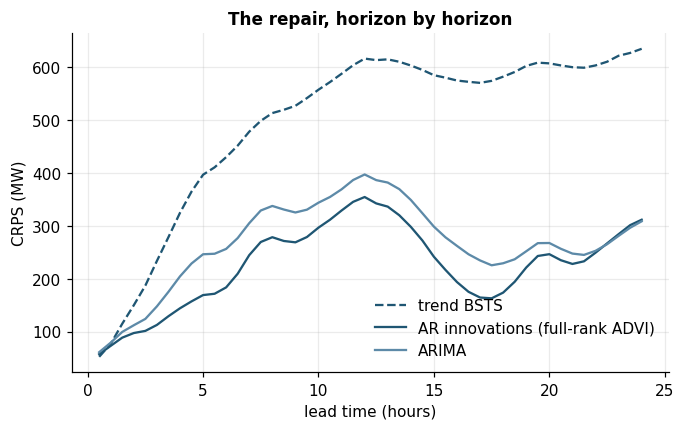

In [12]:
ar_curve = per_horizon_crps(ar_fits["fullrank"][0]["forecast_paths"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hours, trend_curve, color=palette("demand"), ls="--", label="trend BSTS")
ax.plot(hours, ar_curve, color=palette("demand"), label="AR innovations (full-rank ADVI)")
ax.plot(hours, arima_curve, color=palette("forecast"), label="ARIMA")
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("CRPS (MW)")
ax.set_title("The repair, horizon by horizon")
ax.legend()
save_figure(fig, "bsts_repair_by_horizon", cfg.paths.figures)
plt.show()

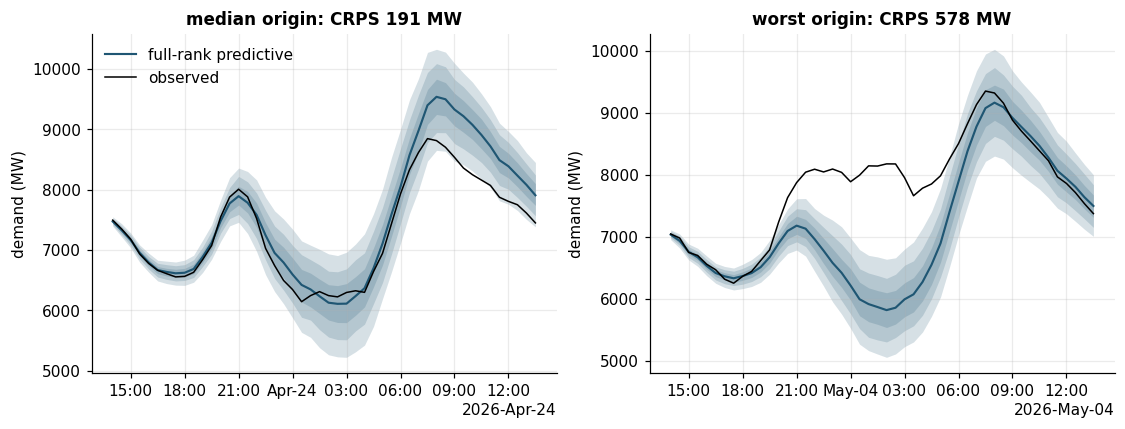

In [13]:
fr_paths = ar_fits["fullrank"][0]["forecast_paths"]
daily_crps = np.stack(
    [crps_samples(y_test[i], fr_paths[:, i, :]).mean() for i in range(y_test.shape[0])]
)
typical = int(np.argsort(daily_crps)[len(daily_crps) // 2])
worst = int(daily_crps.argmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pos, title in ((axes[0], typical, "median origin"), (axes[1], worst, "worst origin")):
    origin = test_origins[pos]
    index = pd.date_range(origin, periods=cfg.horizon, freq="30min")
    fan_chart(
        ax,
        index,
        samples=fr_paths[:, pos, :],
        colour=palette("demand"),
        label="full-rank predictive",
    )
    ax.plot(
        index.tz_convert("Australia/Brisbane"), y_test[pos], color="black", lw=1.0, label="observed"
    )
    ax.set_title(f"{title}: CRPS {daily_crps[pos]:.0f} MW")
    ax.set_ylabel("demand (MW)")
axes[0].legend()
save_figure(fig, "bsts_vi_fan_charts", cfg.paths.figures)
plt.show()

## The decomposition after the repair

Two components now. The origin residual is observed, so the state term
is structurally zero and process plus observation merge into one
**innovation** term that accumulates towards the stationary error
variance as $\rho^{2h}$ decays; **parameter** spread is all the
epistemic uncertainty there is. The epistemic share doubles as an
inference diagnostic: an under-dispersed surrogate must under-state it,
which notebook 04 checks against NUTS.

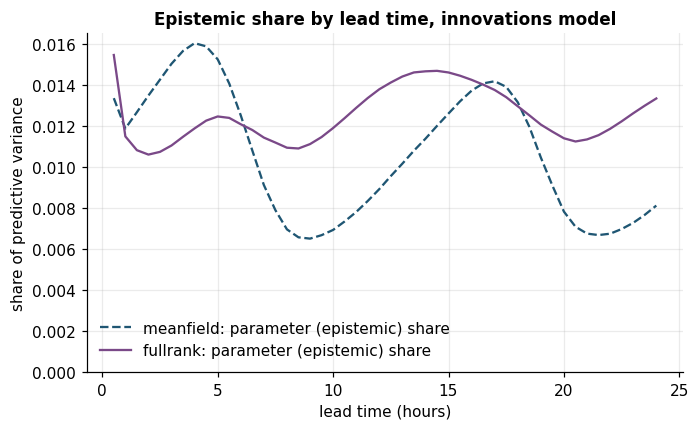

In [14]:
ar_decomp = {
    kind: variance_decomposition_innovations(ar_draws(kind), inputs, panel, cfg, test_origins)
    for kind in ar_fits
}

fig, ax = plt.subplots(figsize=(7, 4))
for kind, ls in (("meanfield", "--"), ("fullrank", "-")):
    parts = ar_decomp[kind]
    total = parts["parameter"] + parts["innovation"]
    ax.plot(
        hours,
        (parts["parameter"] / total).mean(axis=0),
        color=colours[kind],
        ls=ls,
        label=f"{kind}: parameter (epistemic) share",
    )
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("share of predictive variance")
ax.set_ylim(0, None)
ax.set_title("Epistemic share by lead time, innovations model")
ax.legend()
save_figure(fig, "innovations_variance_decomposition", cfg.paths.figures)
plt.show()

In [15]:
rows = {}
for kind in ar_fits:
    parts = ar_decomp[kind]
    total = parts["parameter"] + parts["innovation"]
    rows[kind] = {
        "parameter share": float((parts["parameter"] / total).mean()),
        "innovation share": float((parts["innovation"] / total).mean()),
        "mean predictive sd (MW)": float(np.sqrt(total.mean())),
    }
pd.DataFrame(rows).T.round(3)

,parameter share,innovation share,mean predictive sd (MW)
meanfield,0.011,0.989,336.474
fullrank,0.013,0.987,337.530


## Summary

- All three inference routes agree on the trend model's forecasts, so
  its failure is structural: process noise dominates the decomposition
  and the 48-step CRPS lands behind the seasonal naive.
- The innovations-form AR(1) keeps the regression and the
  heteroskedastic scale, replaces the trend with the stationary error
  the ARIMA order pointed to, fits in seconds rather than most of an
  hour and restores sensible horizon behaviour.
- The decomposition made the diagnosis specific; after the repair it
  reduces to a parameter/innovation split whose epistemic share
  notebook 04 audits against NUTS.